# Group Information  
- **Group No:** 129  
- **Members:**  
  - Elluru Sai Gagan – 2024AB05190  
  - Amulya Gupta – 2024AB05200  
  - Akash Shivadas Chatake – 2024AB05226  
  - Kintul Upadhyay – 2024AB05261  

# Journal Used for Implementation  
- **Title:** *Sentiment Analysis of IMDb Movie Reviews Using Long Short-Term Memory*  
- **Authors:** Muhammad Qaisar, Ammara Nosheen, Hafeez Ur Rehman Siddiqui  
- **Venue/Journal, Year:** *International Journal of Advanced Computer Science and Applications (IJACSA)*, 2020  
- **Citation (APA 7th):**  
  Qaisar, M., Nosheen, A., & Siddiqui, H. U. R. (2020). Sentiment analysis of IMDb movie reviews using long short-term memory. *International Journal of Advanced Computer Science and Applications (IJACSA), 11*(5), 386–394. https://doi.org/10.14569/IJACSA.2020.0110549  
- **Link/DOI:** [https://doi.org/10.14569/IJACSA.2020.0110549](https://doi.org/10.14569/IJACSA.2020.0110549)  


# Library Imports

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras import models
import keras
from keras import regularizers

In [ ]:
import os
import re
import shutil
import string
import numpy as np
import seaborn as sns
import pickle

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, RocCurveDisplay
from sklearn.metrics import roc_curve, auc

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Acquiring the Dataset

In [ ]:
# accessing the imdb dataset
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

dataset = tf.keras.utils.get_file("aclImdb_v1", url,
                                    untar=True, cache_dir='.',
                                    cache_subdir='')

datasetDir = os.path.join(os.path.dirname(dataset), 'aclImdb_v1')

84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# list of contents of the dataset main directory
os.listdir(datasetDir)

['aclImdb']

In [ ]:
# exploring the training section
trainDir = os.path.join(datasetDir, 'aclImdb/train')
os.listdir(trainDir)

['unsup',
 'urls_pos.txt',
 'labeledBow.feat',
 'pos',
 'urls_unsup.txt',
 'neg',
 'urls_neg.txt',
 'unsupBow.feat']

In [ ]:
# positive reviews
os.listdir(os.path.join(trainDir, "pos"))[:10]

['4162_10.txt',
 '8076_7.txt',
 '3822_10.txt',
 '11517_9.txt',
 '432_8.txt',
 '10353_9.txt',
 '699_8.txt',
 '6517_10.txt',
 '231_10.txt',
 '7925_7.txt']

In [ ]:
# opening a sample negative review
with open(os.path.join(os.path.join(trainDir, "neg"),
                       os.listdir(os.path.join(trainDir, "neg"))[80])) as f:
  print(f.read())

Basically this is about a couple who want to adopt a second child. At the adoption agency they meet a mouse (Stuart) and they decide to adopt him. If you think that this is stupid, hold it, because it's getting worse.<br /><br />Stuart arrives to his new home, where he is treated like a human child. (Spare me!) The rest is pretty much the usual cliché, about family problems, jealousy from the elder "brother", and at the end all issues are resolved and they are all a "happy family". Boring and worn out as this is, it is also shown in the most blunt and unsophisticated way.<br /><br />I don't know if the director believed that he was being creative by introducing a mouse to the cliché, or he was just trying to fill in minutes, but he only upgraded the cliché from boring to abhorrent.<br /><br />Then why I gave a 3 and not a ZERO? Because of the family cat, who loves Stuart as much as the "brother". And because of some funny gigs, where Stuart makes good use of his small size.<br /><br />

In [ ]:
# removing the unsup subdirectory
shutil.rmtree(os.path.join(trainDir, "unsup"))
os.listdir(trainDir)

['urls_pos.txt',
 'labeledBow.feat',
 'pos',
 'urls_unsup.txt',
 'neg',
 'urls_neg.txt',
 'unsupBow.feat']

# Data Partitioning

In [ ]:
# the dataset already has two partitions
# in the test and train subdirectories
# train will be partitioned into train and validation

# partition ratio - validation as a fraction of train whole
PARTITION_VAL = 0.2

In [ ]:
BATCH_SIZE = 128
SEED = 42

In [ ]:
# train partition 1 without preprocessing
rawTrain1 = tf.keras.utils.text_dataset_from_directory(
    os.path.join(datasetDir, 'aclImdb/train'),
    batch_size = BATCH_SIZE,
    validation_split = PARTITION_VAL,
    subset = 'training',
    seed =  SEED
    )

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


In [ ]:
# few samples of the training partition
for textBatch, labelBatch in rawTrain1.take(1):
  for i in range(20, 30):
    print("Review: ", textBatch.numpy()[i])
    print("Label: ", labelBatch.numpy()[i])
print("Where")
print("Label 0 =", rawTrain1.class_names[0])
print("Label 1 =", rawTrain1.class_names[1])

Review:  b"When I heard the plot for this movie I simply had to see it, I mean whole cities being wiped out by killer tomatoes! Sadly the title is about as funny as it gets.<br /><br />Led by Detective Dick Mason, a special team of military and scientists (including Greg Colburn who never takes his SCUBA outfit off and Lt. Finletter who is never pictured without his parachute trailing behind) 'Attack Of The Killer Tomatoes' is a parody of B-Movies, in particular Japanese horror of the 1950's. The film begins with a standard sized tomato being discovered by a women washing up in her kitchen before we find ourselves in a middle of a crime scene as the tomato has supposedly murdered this lady, and let me tell you it doesn't get any saner as the film progresses! To be fair there are a couple of funny moments, for instance anytime the Japanese scientist Dr Nokitofa speaks his voice is dubbed over in an American accent, or when disguise expert Sam Smith infiltrates the tomatoes 'hey, can som

In [ ]:
# validation partition without preprocessing
rawVal = tf.keras.utils.text_dataset_from_directory(
    os.path.join(datasetDir, 'aclImdb/train'),
    batch_size = BATCH_SIZE,
    validation_split = PARTITION_VAL,
    subset = 'validation',
    seed = SEED
    )

Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [ ]:
# train partition 1 without preprocessing
rawTrain2 = tf.keras.utils.text_dataset_from_directory(
    os.path.join(datasetDir, 'aclImdb/test'),
    batch_size = BATCH_SIZE,
    validation_split = PARTITION_VAL,
    subset = 'training',
    seed =  SEED
    )

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


In [ ]:
# testing partition without preprocessing
rawTest = tf.keras.utils.text_dataset_from_directory(
    os.path.join(datasetDir, 'aclImdb/test'),
    batch_size = BATCH_SIZE,
    validation_split = PARTITION_VAL,
    subset = 'validation',
    seed = SEED
    )

Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [ ]:
# joining training data from the two folders
# to get the final training data
rawTrain = rawTrain1.concatenate(rawTrain2)
rawTrain

<_ConcatenateDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
# few samples of the training partition
for textBatch, labelBatch in rawTrain.take(1):
  for i in range(20, 30):
    print("Review: ", textBatch.numpy()[i])
    print("Label: ", labelBatch.numpy()[i])
print("Where")
print("Label 0 =", rawTrain1.class_names[0])
print("Label 1 =", rawTrain1.class_names[1])

Review:  b'NOTHING (3+ outta 5 stars) Another weird premise from the director of the movie "Cube". This time around there are two main characters who find themselves and their home transported to a mysterious white void. There is literally NOTHING outside of their small two-story house. Intriguing to be sure, but I thought the comedic tone established for this movie from the get-go was extremely ill-conceived. There needs to be some humour, certainly... and I have no problem with the humour that was eventually derived from the plight of our two heroes (their final "showdown" was definitely a hoot)... but I really think the movie would have been a lot better off if it had stayed more rooted in reality in the beginning. After watching the movie I watched the "Making of" feature on the DVD and a short trailer at the end is almost totally devoid of the "sillier" comedic aspects... making it look like a completely different (and slightly better) movie. The last half hour of the movie is whe

# Data Preprocessing

In [ ]:
# removes the HTML tags and punctuation in the given text
def stripHTMLAndPunctuation(inputText):
  noHTML = tf.strings.regex_replace(tf.strings.lower(inputText),
                                    "(<br />)|(</?p>)", ' ')
  return tf.strings.regex_replace(noHTML,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')

In [ ]:
# maximum vocab size
MAX_FEATURES = 10000

# length to text vector
SEQ_LEN = 250

In [ ]:
# layer to create vectors from raw text
vectorizeLayer = layers.TextVectorization(
    standardize = stripHTMLAndPunctuation,
    max_tokens = MAX_FEATURES,
    output_mode = 'int',
    output_sequence_length = SEQ_LEN)

In [ ]:
# adapting the layer to learn the vocab
vectorizeLayer.adapt(rawTrain.map(lambda x, y: x))

In [ ]:
pickle.dump({'config': vectorizeLayer.get_config(),
             'weights': vectorizeLayer.get_weights()}
            , open("/content/tv_layer.pkl", "wb"))

In [ ]:
# exploring the vocab
print(vectorizeLayer.get_vocabulary()[100: 200])
print('Vocabulary size: {}'.format(len(vectorizeLayer.get_vocabulary())))

[np.str_('characters'), np.str_('after'), np.str_('think'), np.str_('watch'), np.str_('many'), np.str_('seen'), np.str_('two'), np.str_('character'), np.str_('being'), np.str_('never'), np.str_('love'), np.str_('acting'), np.str_('plot'), np.str_('did'), np.str_('where'), np.str_('best'), np.str_('know'), np.str_('little'), np.str_('show'), np.str_('life'), np.str_('ever'), np.str_('does'), np.str_('your'), np.str_('better'), np.str_('end'), np.str_('off'), np.str_('over'), np.str_('still'), np.str_('these'), np.str_('say'), np.str_('scene'), np.str_('man'), np.str_('here'), np.str_('why'), np.str_('while'), np.str_('scenes'), np.str_('such'), np.str_('something'), np.str_('go'), np.str_('through'), np.str_('should'), np.str_('im'), np.str_('those'), np.str_('back'), np.str_('real'), np.str_('watching'), np.str_('now'), np.str_('thing'), np.str_('didnt'), np.str_('doesnt'), np.str_('actors'), np.str_('years'), np.str_('though'), np.str_('another'), np.str_('before'), np.str_('funny'), 

In [ ]:
# vectorizes the text
def vectorizeText(inputText, label):
  return vectorizeLayer(tf.expand_dims(inputText, -1)), label

In [ ]:
# explore effect of vectorization on a review
textBatch, labelBatch = next(iter(rawTrain))
print("Review:", textBatch[BATCH_SIZE // 2])
print("Label:", rawTrain1.class_names[labelBatch[BATCH_SIZE // 2]])
print("Vectorized review:", vectorizeText(textBatch[BATCH_SIZE // 2],
                                           labelBatch[BATCH_SIZE // 2]))

Review: tf.Tensor(b'This movie was so great! I am a teenager, and I and my friends all love the series, so it just goes to show that these movies draw attention to all age crowds. I recommend it to everyone. My favorite line in this movie is when Logan Bartholomew says: "rosy cheeks", when he is talking about his baby daughter. He is such a great actor, as well as Erin Cottrell. They pair up so well, and have such a great chemistry! I really hope that they can work again together. They are such attractive people, and are very good actors. I have finally found movies that are good to watch. Lately it has been hard for me to find movies that are good, and show good morals, and Christian values. But at the same time, these movies aren\'t cheesy.', shape=(), dtype=string)
Label: pos
Vectorized review: (<tf.Tensor: shape=(1, 250), dtype=int64, numpy=
array([[  11,   17,   13,   37,   81,   10,  230,    4, 2224,    3,   10,
           3,   53,  329,   31,  110,    2,  208,   37,    9,   40, 

In [ ]:
# vectorizing the train, validation, and test data
trainData = rawTrain.map(vectorizeText)
valData = rawVal.map(vectorizeText)
testData = rawTest.map(vectorizeText)

# Caching for Speed

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
trainData = trainData.cache().prefetch(buffer_size = AUTOTUNE)
valData = valData.cache().prefetch(buffer_size = AUTOTUNE)
testData = testData.cache().prefetch(buffer_size = AUTOTUNE)

# LSTM Model

In [ ]:
# embedding layer output size
EMBEDDING_DIM = 64

In [ ]:
# model definition
modelLSTM = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim = MAX_FEATURES + 1,
        output_dim = EMBEDDING_DIM,
        mask_zero=True),
    #tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(200)),
    tf.keras.layers.LSTM(200),
    #tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation = "relu"),
    tf.keras.layers.Dense(1)
])

In [ ]:
modelLSTM.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

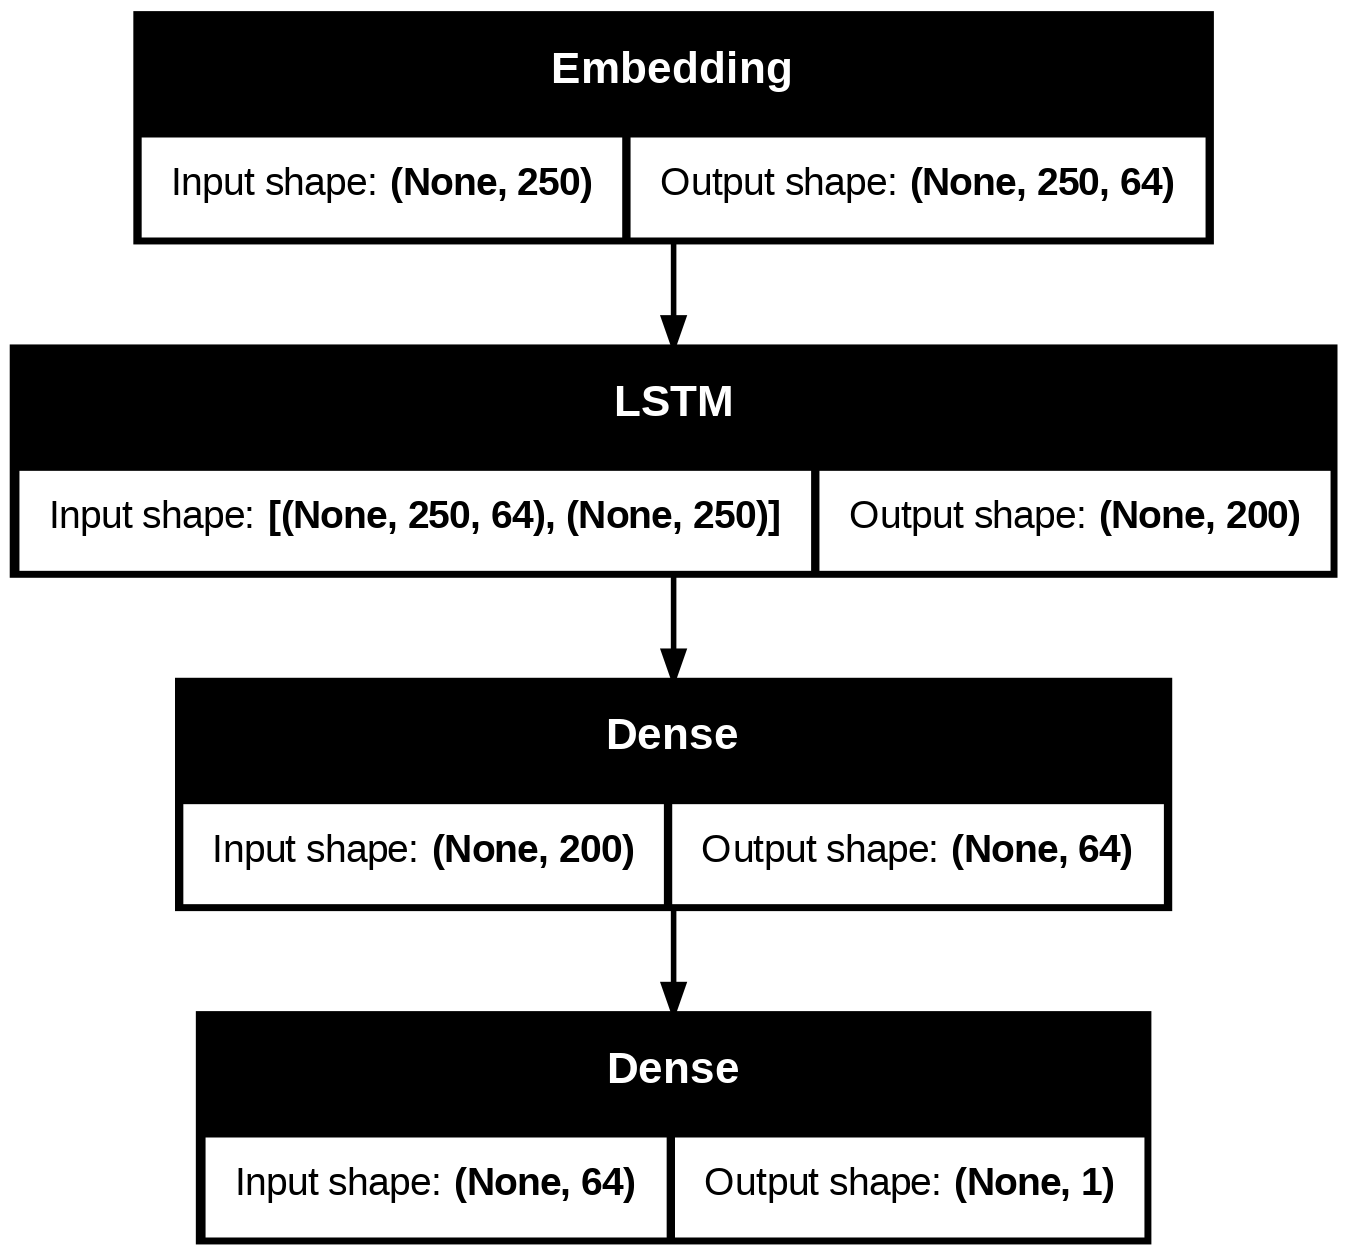

In [ ]:
from tensorflow.keras.utils import plot_model
modelLSTM.build(input_shape=(None, SEQ_LEN))
plot_model(modelLSTM, show_shapes = True)

In [ ]:
modelLSTM.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

In [ ]:
EPOCHS_LSTM = 5

In [ ]:
# model training
history = modelLSTM.fit(
    trainData,
    validation_data = valData,
    epochs = EPOCHS_LSTM)

Epoch 1/5
314/314 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.5609 - loss: 0.6480 - val_accuracy: 0.8224 - val_loss: 0.3996
Epoch 2/5
314/314 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8564 - loss: 0.3431 - val_accuracy: 0.8722 - val_loss: 0.3255
Epoch 3/5
314/314 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8972 - loss: 0.2619 - val_accuracy: 0.8730 - val_loss: 0.3013
Epoch 4/5
314/314 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9127 - loss: 0.2353 - val_accuracy: 0.8780 - val_loss: 0.3205
Epoch 5/5
314/314 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.9222 - loss: 0.2134 - val_accuracy: 0.8714 - val_loss: 0.4123


In [ ]:
# evaluation on test dataset
testLoss, testAccuracy = modelLSTM.evaluate(testData)
!mkdir -p modelLSTM
modelLSTM.save('/content/modelLSTM/modelLSTM.keras')

print("Loss: ", testLoss)
print("Accuracy: ", testAccuracy)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8783 - loss: 0.3923
Loss:  0.38509806990623474
Accuracy:  0.8755999803543091


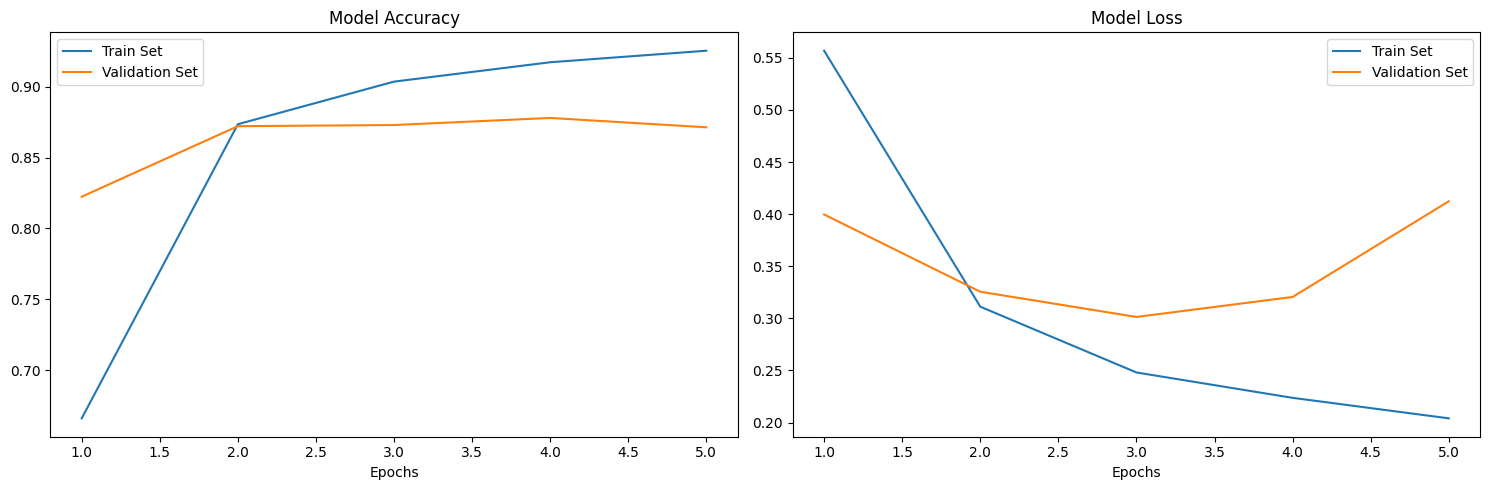

In [ ]:
# plotting training loss and accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, EPOCHS_LSTM + 1)

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Set')
plt.plot(epochs_range, val_acc, label='Validation Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Set')
plt.plot(epochs_range, val_loss, label='Validation Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.title('Model Loss')

plt.tight_layout()
plt.show()

In [ ]:
yPred = np.array(modelLSTM.predict(testData) >= 0)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [ ]:
yPred

array([[ True],
       [ True],
       [ True],
       ...,
       [ True],
       [False],
       [ True]])

In [ ]:
testData

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 250), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
yActual = np.concatenate([y for x, y in testData], axis=0)

In [ ]:
yActual.shape

(5000,)

In [ ]:
yPredNumeric = np.reshape(1 * yPred, (yPred.shape[0],))
print(yPredNumeric, yPredNumeric.shape, sep = "\n")

[1 1 1 ... 1 0 1]
(5000,)


In [ ]:
# model evaluation
print("accuracy of LSTM based model = {}".format(accuracy_score(yActual, yPredNumeric)))
print(classification_report(yActual, yPredNumeric))

accuracy of LSTM based model = 0.874
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      2462
           1       0.87      0.89      0.88      2538

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



<Axes: >

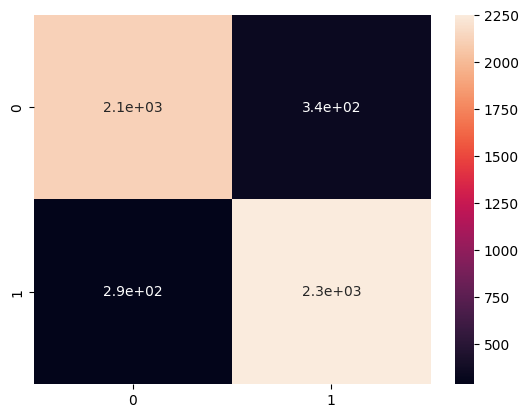

In [ ]:
# confusion matrix
cfm = confusion_matrix(yActual, yPredNumeric)
sns.heatmap(cfm, annot = True)

In [ ]:
tn, fp, fn, tp = confusion_matrix(yActual, yPredNumeric).ravel()
print("specificity =", tn / (tn + fp))

specificity = 0.8602761982128351


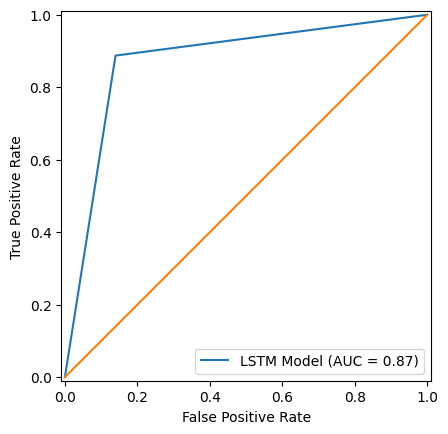

In [ ]:
# ROC curve
fpr, tpr, thresholds = roc_curve(yActual, yPredNumeric)
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='LSTM Model')
display.plot()
plt.plot(fpr, fpr)
plt.show()

# CNN Based Model

In [ ]:
LAMBDA = 0.0001

In [ ]:
# model definition
modelCNN = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim = MAX_FEATURES + 1,
        output_dim = EMBEDDING_DIM,
        mask_zero=True),
    tf.keras.layers.Conv1D(filters = 64,
                           kernel_regularizer=regularizers.l2(LAMBDA),
                           kernel_initializer='he_uniform',
                           kernel_size = 3,
                           activation = "relu"),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv1D(filters = 32, kernel_size = 2,
                           kernel_regularizer=regularizers.l2(LAMBDA),
                           kernel_initializer='he_uniform',
                           activation = "relu"),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, kernel_regularizer=regularizers.l2(LAMBDA),
                          kernel_initializer='he_uniform',
                          activation = "relu"),
    tf.keras.layers.Dense(1)
])

In [ ]:
modelCNN.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


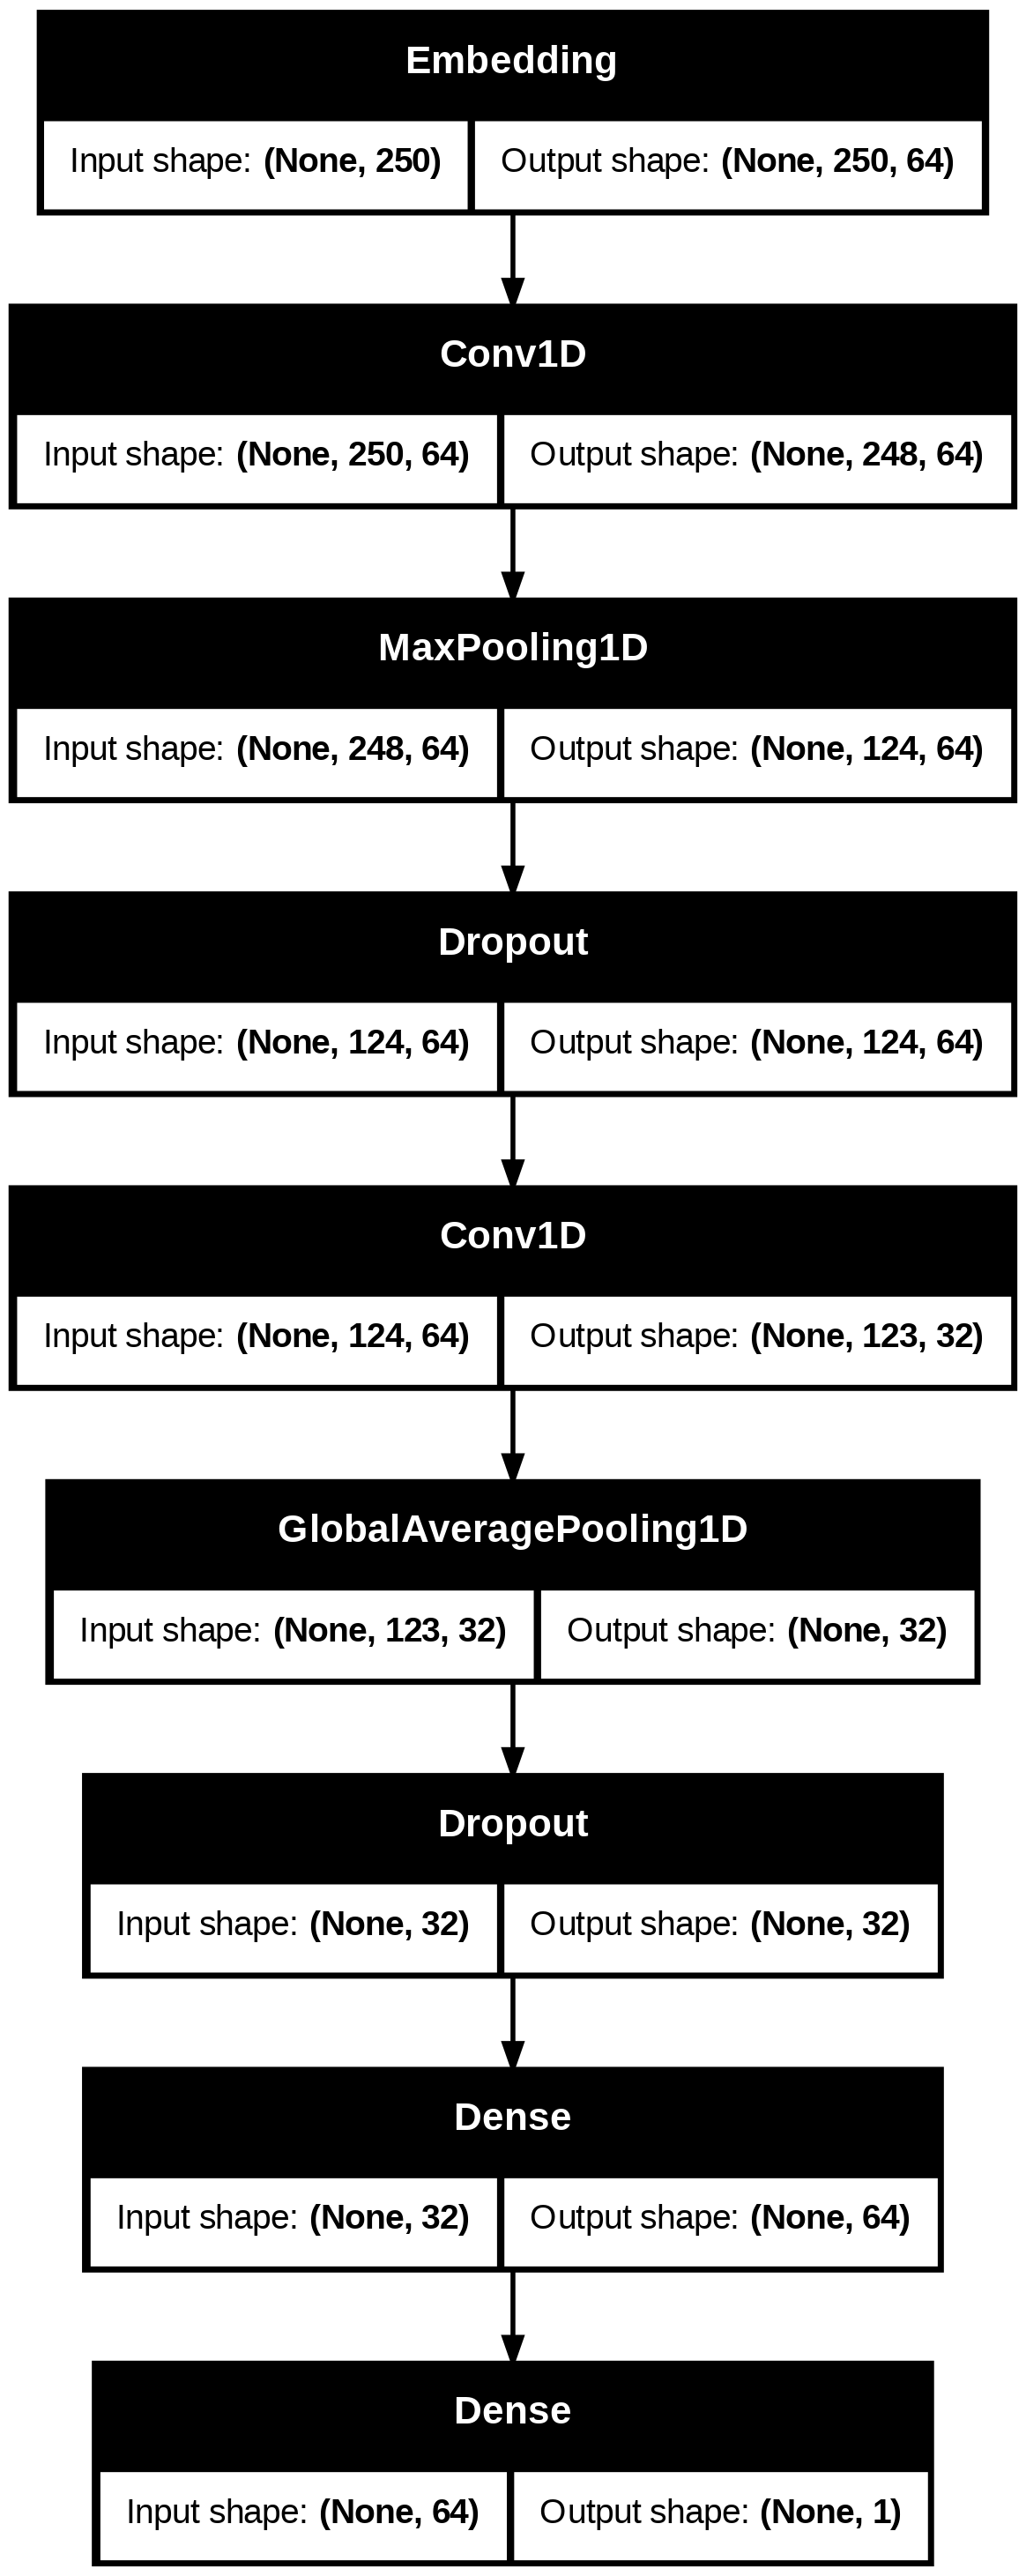

In [ ]:
from tensorflow.keras.utils import plot_model
modelCNN.build(input_shape=(None, SEQ_LEN))
plot_model(modelCNN, show_shapes = True)

In [ ]:
modelCNN.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

In [ ]:
EPOCHS_CNN = 8

In [ ]:
# model training
history = modelCNN.fit(
    trainData,
    validation_data = valData,
    epochs = EPOCHS_CNN)

Epoch 1/8


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


314/314 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.5036 - loss: 0.7226 - val_accuracy: 0.4924 - val_loss: 0.6908
Epoch 2/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5565 - loss: 0.6369 - val_accuracy: 0.8376 - val_loss: 0.4135
Epoch 3/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8275 - loss: 0.4114 - val_accuracy: 0.8610 - val_loss: 0.3457
Epoch 4/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8657 - loss: 0.3497 - val_accuracy: 0.8716 - val_loss: 0.3262
Epoch 5/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8828 - loss: 0.3146 - val_accuracy: 0.8704 - val_loss: 0.3190
Epoch 6/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8926 - loss: 0.2975 - val_accuracy: 0.8734 - val_loss: 0.3160
Epoch 7/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8981 - loss: 0.2815 - val_accuracy: 0.8780 - val_loss: 0.3133
Epoch 8/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9055 - loss: 0.2668 - val_accuracy: 0.8774 - val_loss

In [ ]:
# evaluation on test dataset
testLoss, testAccuracy = modelCNN.evaluate(testData)
!mkdir -p modelCNN
modelCNN.save('/content/modelCNN/modelCNN.keras')

print("Loss: ", testLoss)
print("Accuracy: ", testAccuracy)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8803 - loss: 0.3038
Loss:  0.3052511215209961
Accuracy:  0.8822000026702881


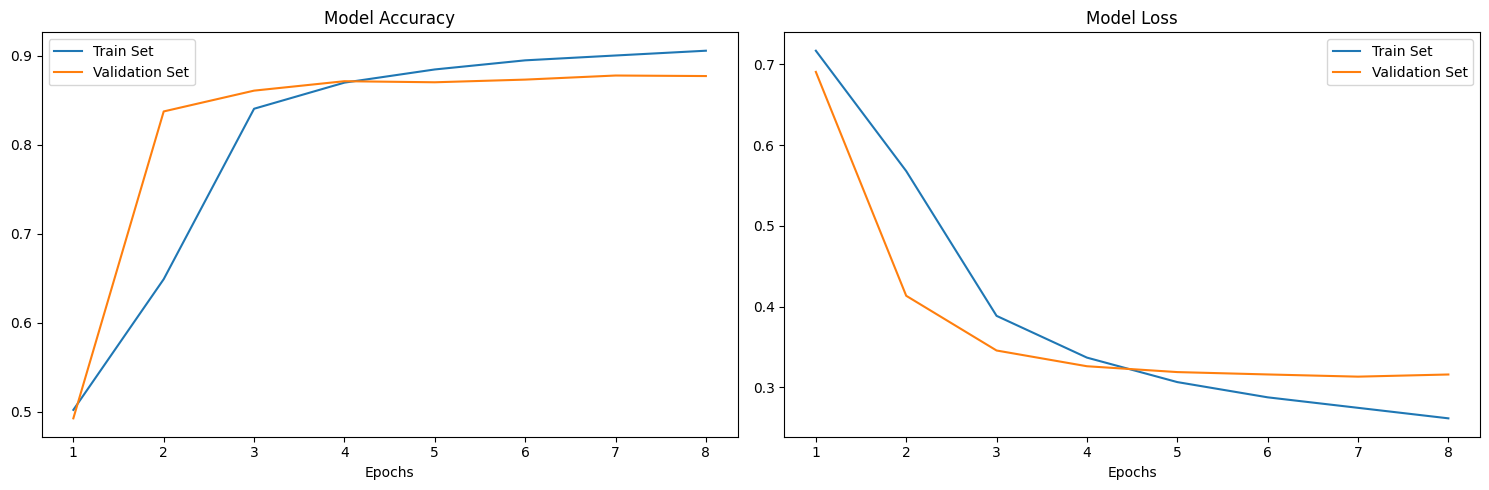

In [ ]:
# plotting training loss and accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, EPOCHS_CNN + 1)

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Set')
plt.plot(epochs_range, val_acc, label='Validation Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Set')
plt.plot(epochs_range, val_loss, label='Validation Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.title('Model Loss')

plt.tight_layout()
plt.show()

In [ ]:
yPred = np.array(modelCNN.predict(testData) >= 0)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [ ]:
yActual = np.concatenate([y for x, y in testData], axis=0)

In [ ]:
yPredNumeric = np.reshape(1 * yPred, (yPred.shape[0],))
print(yPredNumeric, yPredNumeric.shape, sep = "\n")

[1 1 1 ... 1 0 1]
(5000,)


In [ ]:
# model evaluation
print("accuracy of CNN based model = {}".format(accuracy_score(yActual, yPredNumeric)))
print(classification_report(yActual, yPredNumeric))

accuracy of CNN based model = 0.891
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      2462
           1       0.90      0.88      0.89      2538

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



<Axes: >

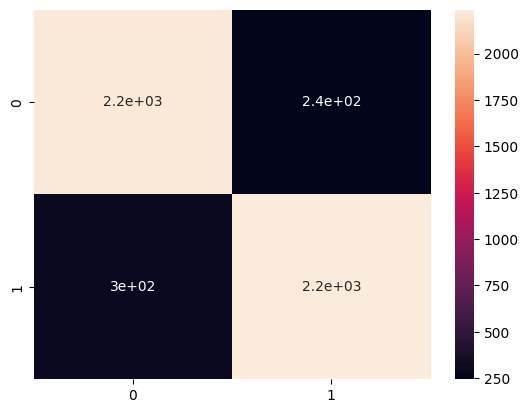

In [ ]:
# confusion matrix
cfm = confusion_matrix(yActual, yPredNumeric)
sns.heatmap(cfm, annot = True)

In [ ]:
tn, fp, fn, tp = confusion_matrix(yActual, yPredNumeric).ravel()
print("specificity =", tn / (tn + fp))

specificity = 0.90089358245329


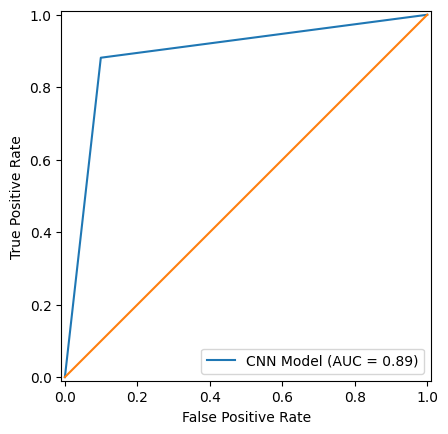

In [ ]:
# ROC curve
fpr, tpr, thresholds = roc_curve(yActual, yPredNumeric)
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='CNN Model')
display.plot()
plt.plot(fpr, fpr)
plt.show()

# LSTM-CNN Based Model

In [ ]:
# model definition
modelCombine = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim = MAX_FEATURES + 1,
        output_dim = EMBEDDING_DIM,
        mask_zero=True),
    tf.keras.layers.LSTM(200,
                         kernel_regularizer=regularizers.l2(LAMBDA),
                         return_sequences = True),
    tf.keras.layers.Conv1D(filters = 64, kernel_size = 3,
                           kernel_regularizer=regularizers.l2(LAMBDA),
                           kernel_initializer='he_uniform',
                           activation = "relu"),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv1D(filters = 32, kernel_size = 2,
                           kernel_regularizer=regularizers.l2(LAMBDA),
                           kernel_initializer='he_uniform',
                           activation = "relu"),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64,
                          kernel_regularizer=regularizers.l2(LAMBDA),
                          kernel_initializer='he_uniform',
                          activation = "relu"),
    tf.keras.layers.Dense(1)
])

In [ ]:
modelCombine.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d_2' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


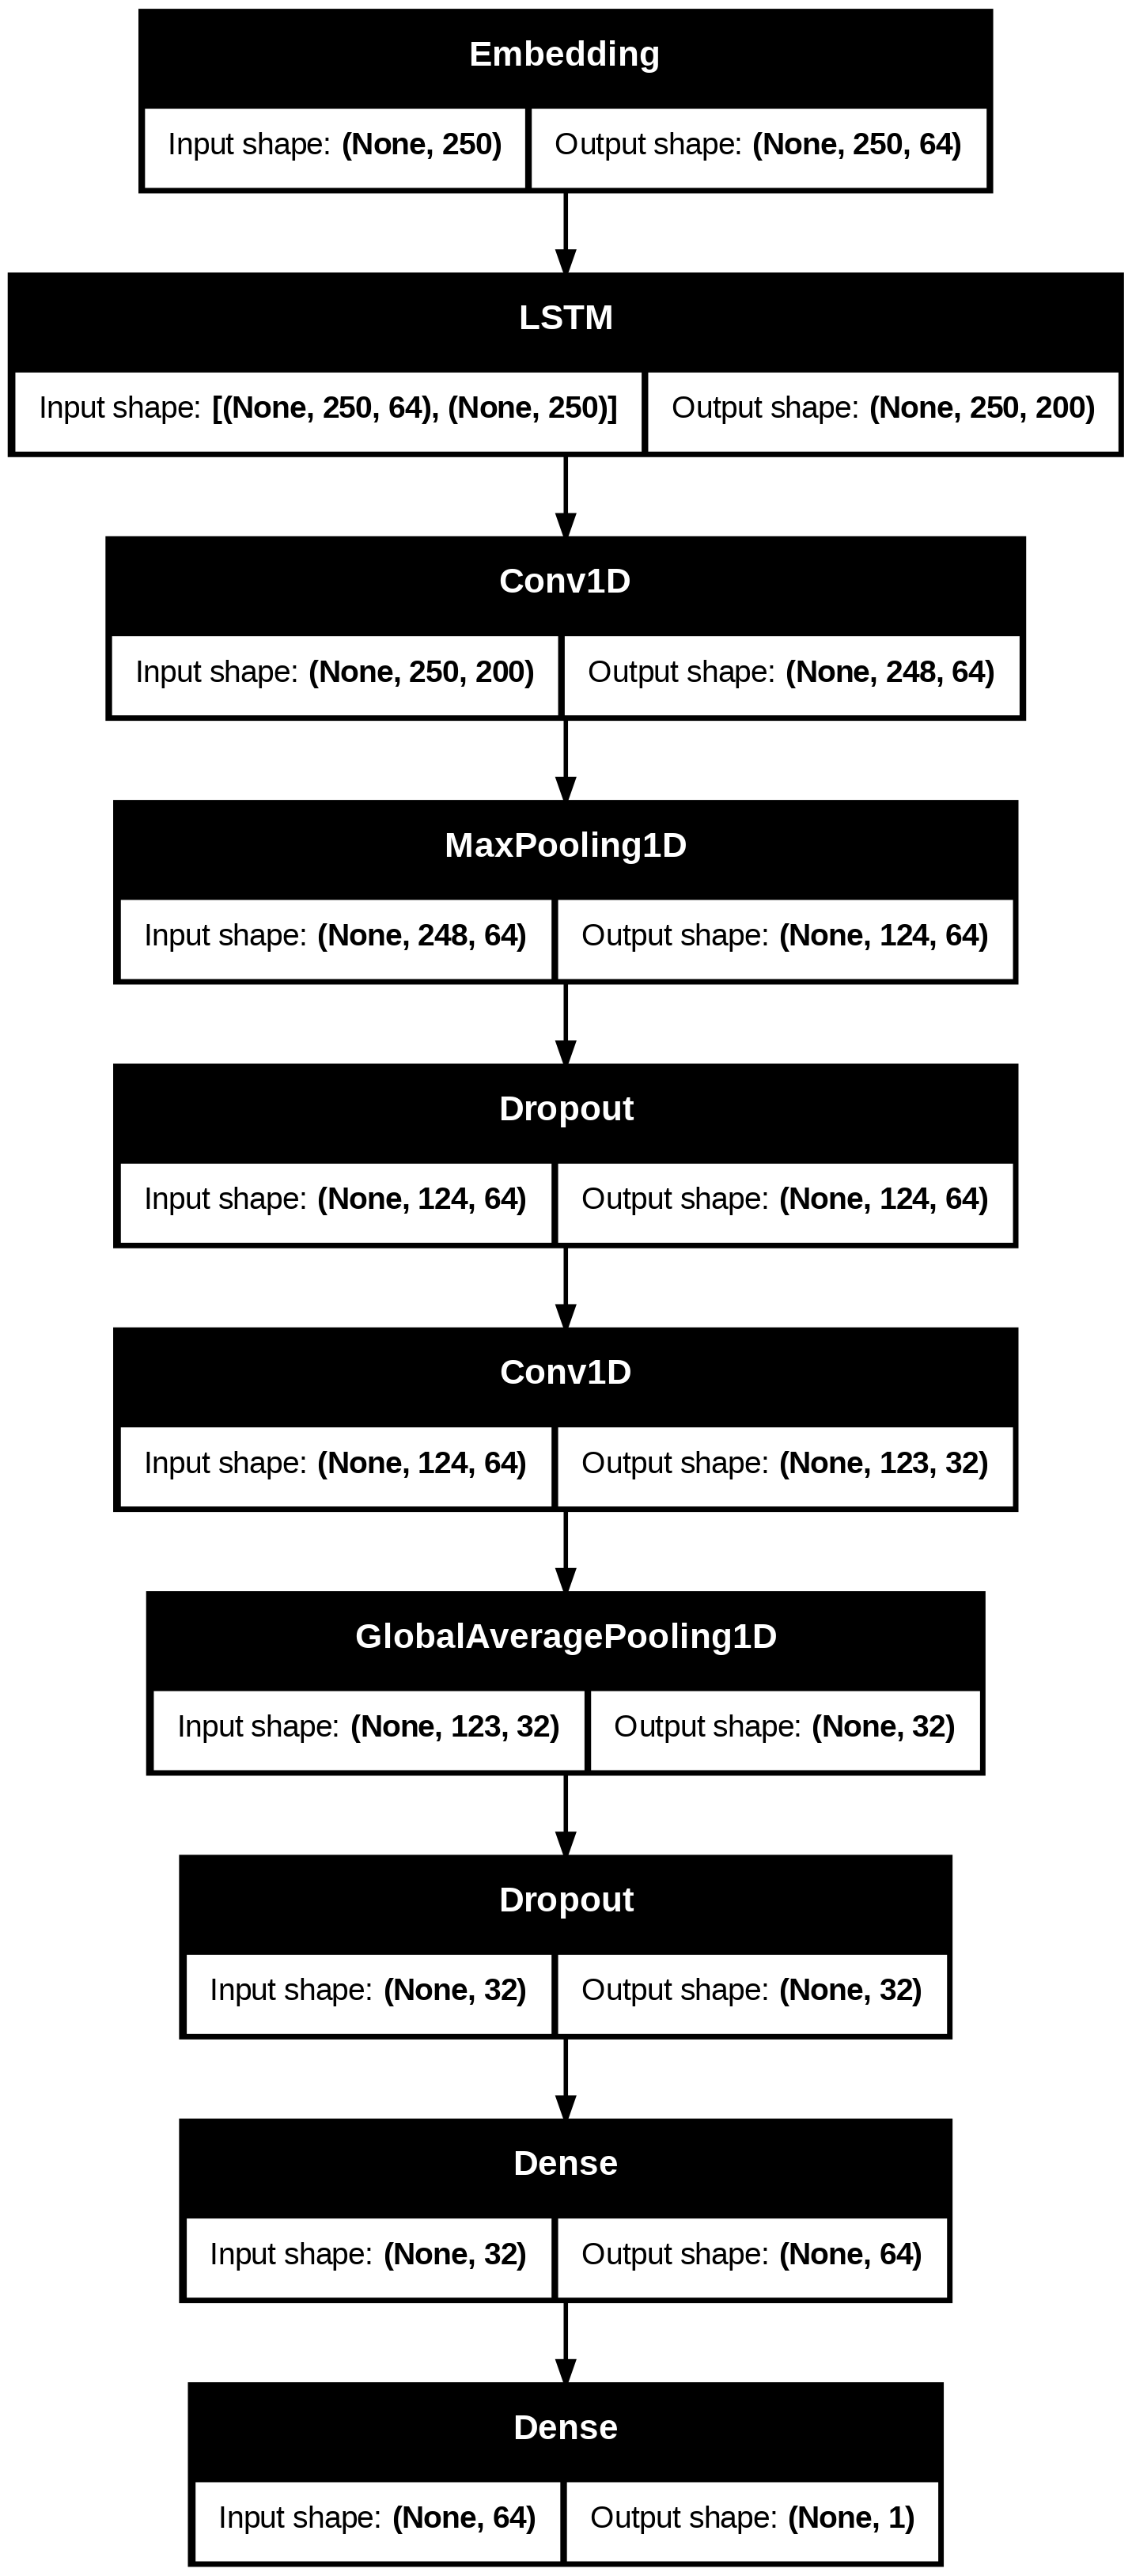

In [ ]:
from tensorflow.keras.utils import plot_model
modelCombine.build(input_shape=(None, SEQ_LEN))
plot_model(modelCombine, show_shapes = True)

In [ ]:
modelCombine.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

In [ ]:
EPOCHS_Combine = 6

In [ ]:
# model training
history = modelCombine.fit(
    trainData,
    validation_data = valData,
    epochs = EPOCHS_Combine)

Epoch 1/6


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d_2' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


314/314 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.5371 - loss: 0.7045 - val_accuracy: 0.7758 - val_loss: 0.5162
Epoch 2/6
314/314 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.8181 - loss: 0.4302 - val_accuracy: 0.8464 - val_loss: 0.3884
Epoch 3/6
314/314 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.8789 - loss: 0.3307 - val_accuracy: 0.8514 - val_loss: 0.3853
Epoch 4/6
314/314 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.8951 - loss: 0.2954 - val_accuracy: 0.8614 - val_loss: 0.3767
Epoch 5/6
314/314 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9061 - loss: 0.2665 - val_accuracy: 0.8612 - val_loss: 0.4295
Epoch 6/6
314/314 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.9116 - loss: 0.2523 - val_accuracy: 0.8612 - val_loss: 0.5455


In [ ]:
# evaluation on test dataset
testLoss, testAccuracy = modelCombine.evaluate(testData)
!mkdir -p modelCombine
modelCombine.save('/content/modelCombine/modelCombine.keras')

print("Loss: ", testLoss)
print("Accuracy: ", testAccuracy)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8674 - loss: 0.4933
Loss:  0.5092151165008545
Accuracy:  0.8611999750137329


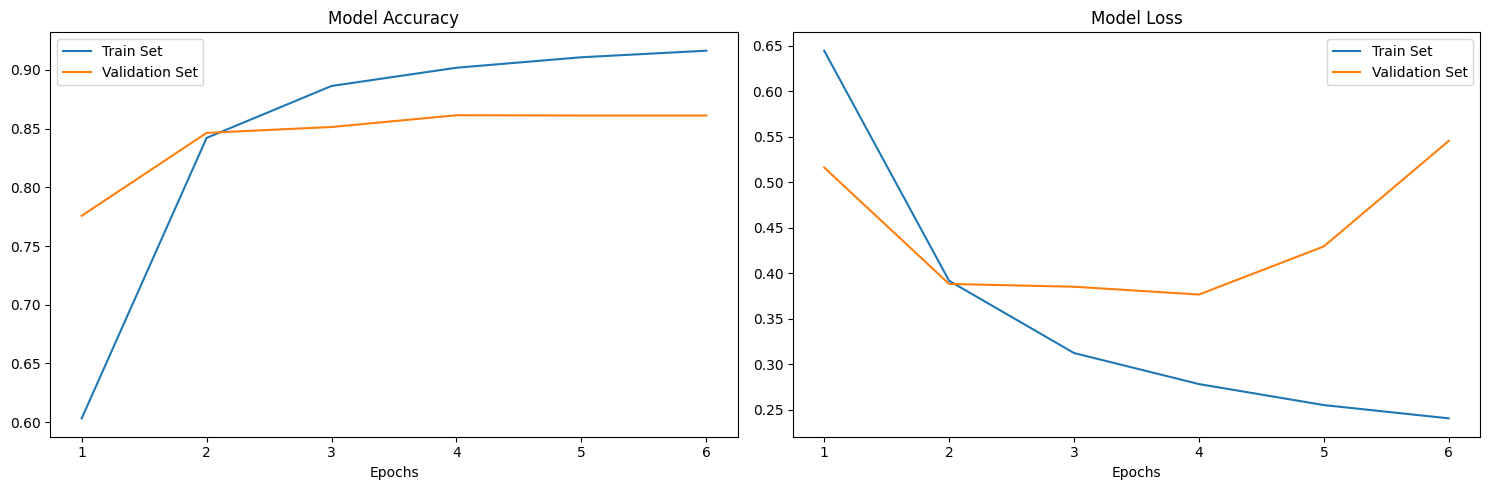

In [ ]:
# plotting training loss and accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, EPOCHS_Combine + 1)

plt.figure(figsize=(15,5))
#plt.axis([0, 7, 0, 1])

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Set')
plt.plot(epochs_range, val_acc, label='Validation Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.title('Model Accuracy')
#plt.axis([0, 7, 0.5, 1])

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Set')
plt.plot(epochs_range, val_loss, label='Validation Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.title('Model Loss')

plt.tight_layout()
#plt.axis([0, 7, 0, 1])
plt.show()

In [ ]:
yPred = np.array(modelCombine.predict(testData) >= 0)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [ ]:
yActual = np.concatenate([y for x, y in testData], axis=0)

In [ ]:
yPredNumeric = np.reshape(1 * yPred, (yPred.shape[0],))
print(yPredNumeric, yPredNumeric.shape, sep = "\n")

[1 1 1 ... 1 0 1]
(5000,)


In [ ]:
# model evaluation
print("accuracy of LSTM-CNN based model = {}".format(accuracy_score(yActual, yPredNumeric)))
print(classification_report(yActual, yPredNumeric))

accuracy of LSTM-CNN based model = 0.8588
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      2462
           1       0.84      0.89      0.87      2538

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



<Axes: >

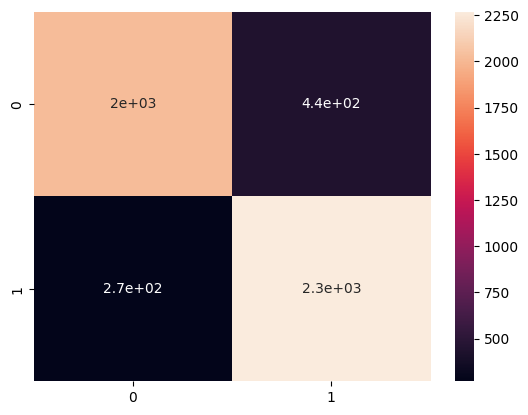

In [ ]:
# confusion matrix
cfm = confusion_matrix(yActual, yPredNumeric)
sns.heatmap(cfm, annot = True)

In [ ]:
tn, fp, fn, tp = confusion_matrix(yActual, yPredNumeric).ravel()
print("specificity =", tn / (tn + fp))

specificity = 0.822502030869212


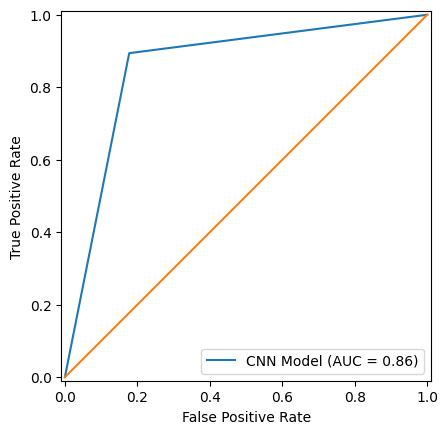

In [ ]:
# ROC curve
fpr, tpr, thresholds = roc_curve(yActual, yPredNumeric)
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='CNN Model')
display.plot()
plt.plot(fpr, fpr)
plt.show()

# Final Note on Implemented Models

In Part B, we implemented three models:
- LSTM (based on Paper 3 by Qaisar, 2020)  
- CNN (based on Paper 1 by Poria et al., 2016)  
- Hybrid LSTM-CNN (inspired by combined approaches)

This was done to provide **comparative validation** across architectures.  
While the assignment requires implementation of **one chosen paper**, we extended the work to also include CNN and Hybrid LSTM-CNN for a deeper evaluation.

# Best Model Conclusion:  
Based on our results:  
- **CNN** achieved the best balance between accuracy (≈89%) and F1-score (0.89), showing strong generalization.  
- **LSTM** achieved higher recall (0.92), making it better at reducing false negatives.  
- **Hybrid LSTM-CNN** had higher training accuracy but slightly lower test generalization (≈86%).  

Therefore, **CNN is identified as the best-performing model overall**, but the additional implementations demonstrate robustness of findings and strengthen the submission.
